# Motor vs potmon vs IMU — common-axis overlay

File: `metadata_20260627_173152.h5`. Azimuth only.

Step 2: put all three streams on **one axis** so agreement is directly visible.

Common axis = **azimuth in degrees**, anchored on the IMU `yaw` (already
physical degrees, after `np.unwrap`). The other two are linearly fit onto it:

- motor `az_pos` (steps) → degrees via `deg = a·steps + b`
- potmon `pot_az_voltage` (V) → degrees via `deg = c·V + d`

The fit slopes are the steps/deg and V/deg calibrations; the residual panel
shows where each sensor disagrees with the IMU (backlash, hysteresis,
non-linearity, drift).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from eigsep_observing.io import read_metadata_hdf5

FNAME = "metadata_20260627_173152.h5"
here = Path.cwd()
data_path = next(
    (p / FNAME for p in [here, *here.parents] if (p / FNAME).exists()), None
)
assert data_path is not None, f"could not find {FNAME} above {here}"
meta = read_metadata_hdf5(data_path)

STREAMS = ["motor", "potmon", "imu_az"]
T0 = min(
    s["_ts_unix"] for k in STREAMS for s in meta[k] if s is not None
)


def series(stream, field, drop_error=True):
    """Sorted (t_seconds_since_T0, values) for one field; drops None/error."""
    rows = []
    for s in meta[stream]:
        if s is None:
            continue
        if drop_error and s.get("status") == "error":
            continue
        val = s.get(field)
        if val is None:
            continue
        rows.append((s["_ts_unix"] - T0, val))
    rows.sort(key=lambda r: r[0])
    t = np.array([r[0] for r in rows])
    y = np.array([r[1] for r in rows])
    return t, y

In [2]:
# IMU yaw is the reference degrees axis: unwrap on its own time series.
t_imu, yaw_raw = series("imu_az", "yaw")
imu_deg = np.unwrap(yaw_raw, period=360.0)
print(f"imu yaw unwrapped span: {imu_deg.max() - imu_deg.min():.1f} deg")

# Interpolate motor and potmon onto the IMU timestamps so all three share
# the same samples. np.interp clamps at the edges (fine; spans match).
t_m, steps = series("motor", "az_pos")
t_p, volts = series("potmon", "pot_az_voltage")
steps_i = np.interp(t_imu, t_m, steps)
volts_i = np.interp(t_imu, t_p, volts)

# Linear fits onto the IMU degrees axis.
a, b = np.polyfit(steps_i, imu_deg, 1)   # deg = a*steps + b
c, d = np.polyfit(volts_i, imu_deg, 1)   # deg = c*V + d
motor_deg = a * steps_i + b
pot_deg = c * volts_i + d


def rms(x):
    return float(np.sqrt(np.mean(x ** 2)))


print(f"motor:  {1 / a:8.2f} steps/deg   residual RMS {rms(motor_deg - imu_deg):6.2f} deg")
print(f"potmon: {1 / c * 1e3:8.2f} mV/deg     residual RMS {rms(pot_deg - imu_deg):6.2f} deg")
print(f"motor–pot direct: residual RMS {rms(motor_deg - pot_deg):6.2f} deg")

imu yaw unwrapped span: 212.9 deg
motor:    -97.68 steps/deg   residual RMS  19.39 deg
potmon:    -3.51 mV/deg     residual RMS   2.66 deg
motor–pot direct: residual RMS  19.69 deg


saved /home/christian/Documents/research/eigsep/eigsep_observing/notebooks/motor_pot_imu/02_overlay.png


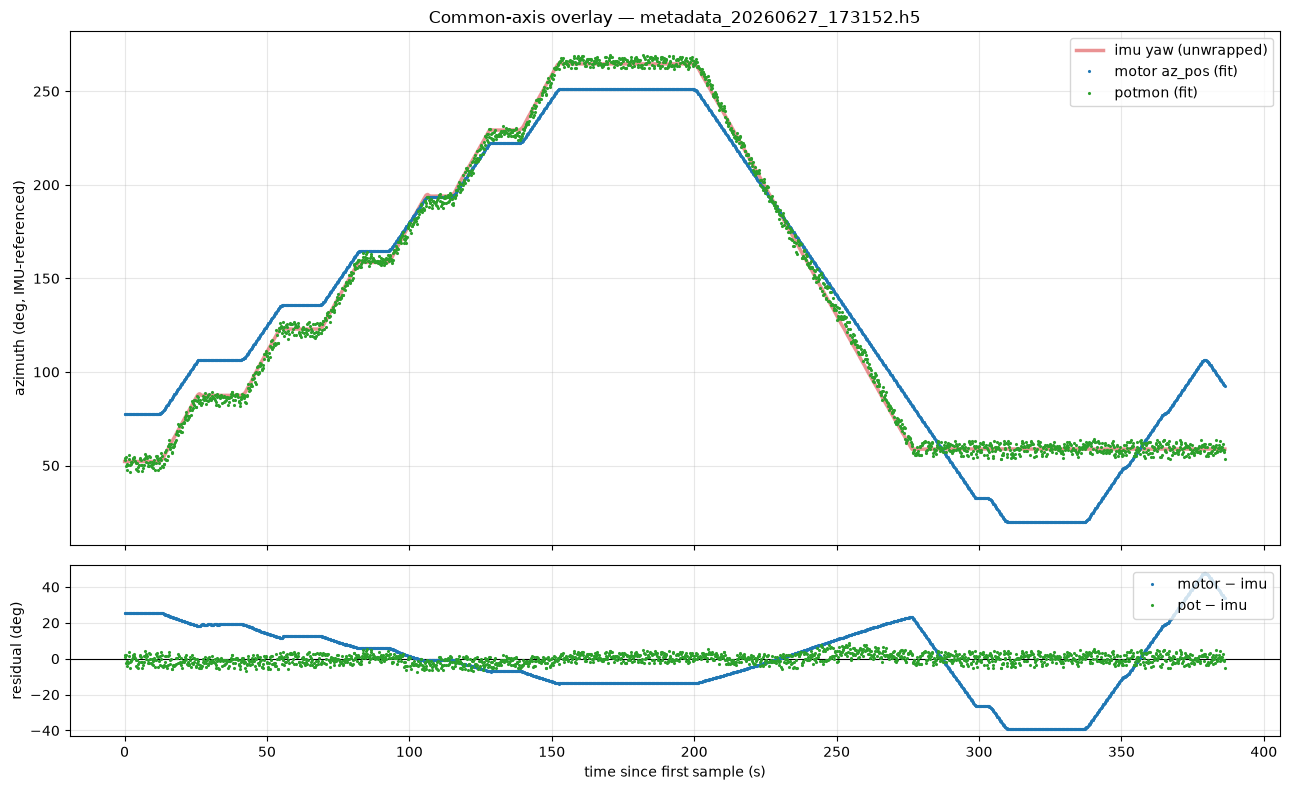

In [3]:
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(13, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# --- overlay on common degrees axis ---
ax0.plot(t_imu, imu_deg, "-", lw=2.5, alpha=0.5, color="tab:red", label="imu yaw (unwrapped)")
ax0.plot(t_imu, motor_deg, ".", ms=2.5, color="tab:blue", label="motor az_pos (fit)")
ax0.plot(t_imu, pot_deg, ".", ms=2.5, color="tab:green", label="potmon (fit)")
ax0.set_ylabel("azimuth (deg, IMU-referenced)")
ax0.legend(loc="upper right")
ax0.grid(alpha=0.3)
ax0.set_title("Common-axis overlay \u2014 metadata_20260627_173152.h5")

# --- residuals vs IMU ---
ax1.axhline(0, color="k", lw=0.8)
ax1.plot(t_imu, motor_deg - imu_deg, ".", ms=2.5, color="tab:blue", label="motor − imu")
ax1.plot(t_imu, pot_deg - imu_deg, ".", ms=2.5, color="tab:green", label="pot − imu")
ax1.set_ylabel("residual (deg)")
ax1.set_xlabel("time since first sample (s)")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)

fig.tight_layout()
out = Path.cwd() / "02_overlay.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print("saved", out)